Using device: cuda

--- Epoch 1/100 ---
Train Loss: 36.3562 | Val Loss: 37.4255 | R²: -20.6781 | RMSE: 6.2517
New best model saved! Val Loss: 37.4255

--- Epoch 2/100 ---
Train Loss: 23.7167 | Val Loss: 30.8799 | R²: -16.7616 | RMSE: 5.6588
New best model saved! Val Loss: 30.8799

--- Epoch 3/100 ---
Train Loss: 18.4461 | Val Loss: 24.3649 | R²: -13.0180 | RMSE: 5.0272
New best model saved! Val Loss: 24.3649

--- Epoch 4/100 ---
Train Loss: 14.2090 | Val Loss: 23.4531 | R²: -12.5961 | RMSE: 4.9510
New best model saved! Val Loss: 23.4531

--- Epoch 5/100 ---
Train Loss: 13.6087 | Val Loss: 20.9568 | R²: -11.3432 | RMSE: 4.7174
New best model saved! Val Loss: 20.9568

--- Epoch 6/100 ---
Train Loss: 11.1375 | Val Loss: 19.9287 | R²: -10.8519 | RMSE: 4.6225
New best model saved! Val Loss: 19.9287

--- Epoch 7/100 ---
Train Loss: 11.4128 | Val Loss: 16.7093 | R²: -8.6374 | RMSE: 4.1684
New best model saved! Val Loss: 16.7093

--- Epoch 8/100 ---
Train Loss: 10.3831 | Val Loss: 16.4644 | R²

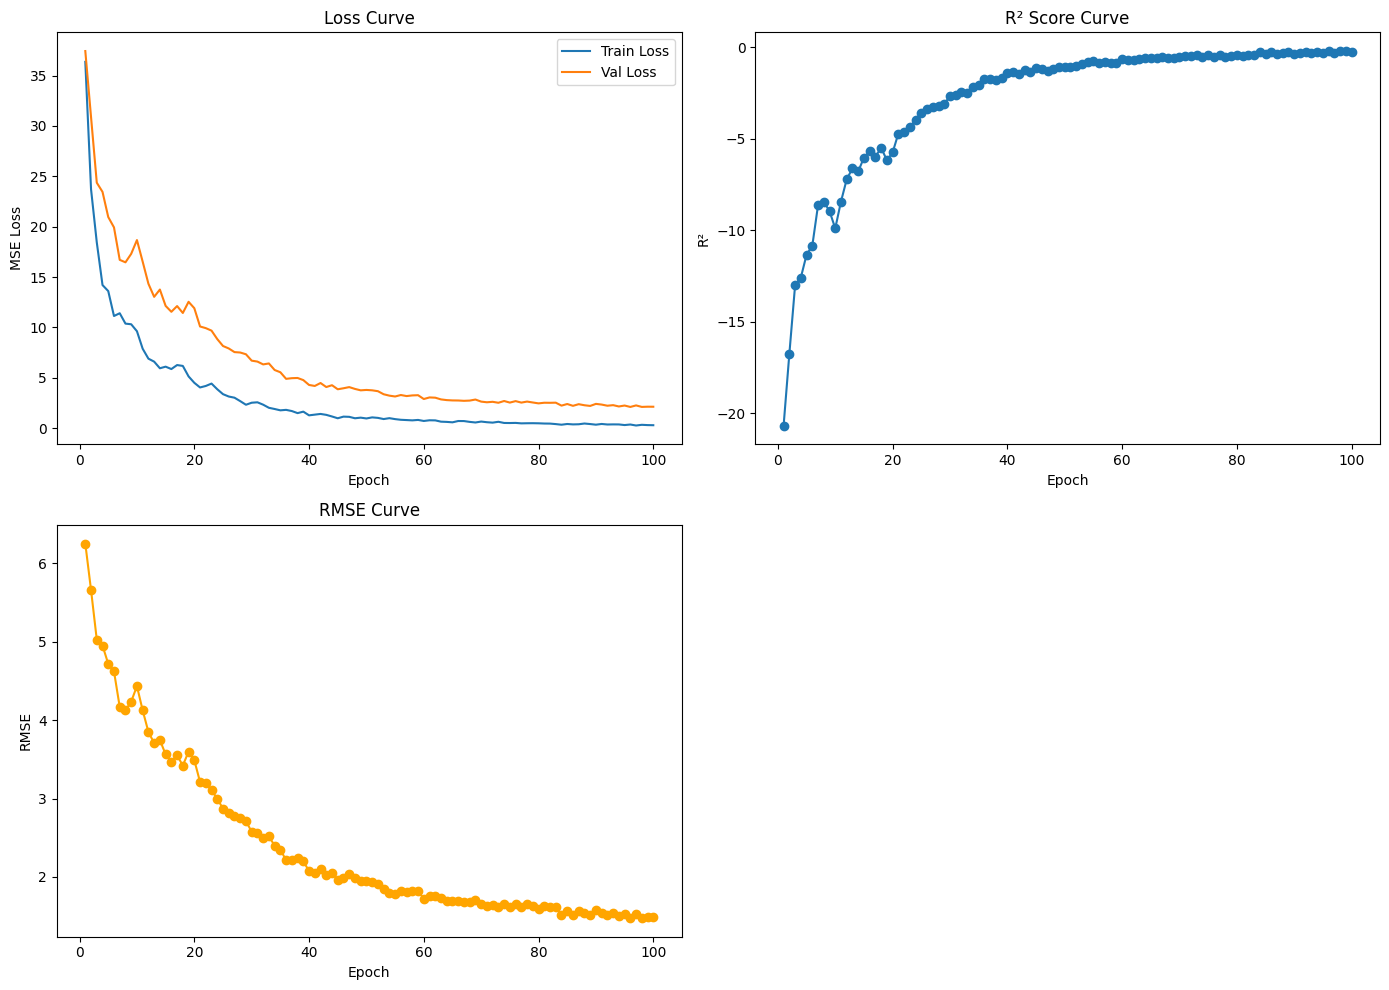

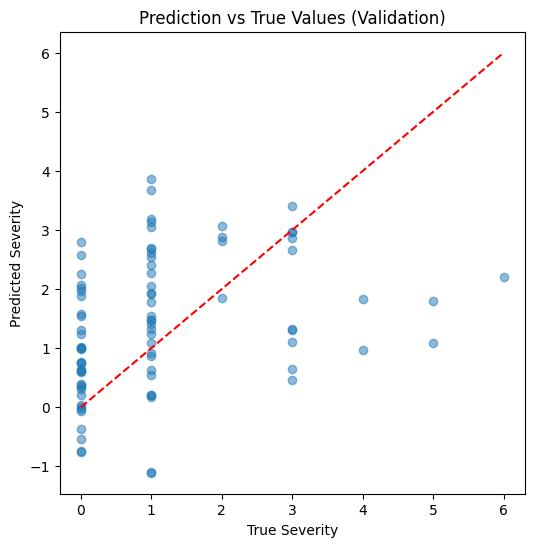

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. Configuration & Hyperparameters ---
DATASET_DIR = "/kaggle/input/severity-dataset/Severity Dataset Final"

TRAIN_DIR = os.path.join(DATASET_DIR, "train/")
VAL_DIR = os.path.join(DATASET_DIR, "valid/")
TEST_DIR = os.path.join(DATASET_DIR, "test/")

TRAIN_CSV = os.path.join(TRAIN_DIR, "train.csv")
VAL_CSV = os.path.join(VAL_DIR, "valid.csv")
TEST_CSV = os.path.join(TEST_DIR, "test.csv")

IMAGE_COLUMN = "image_name"
TARGET_COLUMN = "severity"

MODEL_NAME = 'efficientnet_b0'
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------

# --- 2. Custom Dataset ---
class SeverityDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        if self.df[TARGET_COLUMN].dtype == object:
            self.categories = {k: i for i, k in enumerate(self.df[TARGET_COLUMN].unique())}
            self.df[TARGET_COLUMN] = self.df[TARGET_COLUMN].map(self.categories)
        else:
            self.categories = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row[IMAGE_COLUMN]
        img_path = os.path.join(self.img_dir, img_name)
        image = np.array(Image.open(img_path).convert("RGB"))
        score = torch.tensor(float(row[TARGET_COLUMN]), dtype=torch.float32)

        if self.transform:
            image = self.transform(image=image)["image"]
        
        return image, score

# --- 3. Image Transforms ---
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# --- 4. Training Function ---
def train_fn(loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    for data, targets in loader:
        data = data.to(device)
        targets = targets.view(-1, 1).to(device)
        predictions = model(data)
        loss = loss_fn(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# --- 5. Validation Function ---
def val_fn(loader, model, loss_fn, device):
    model.eval()
    val_loss = 0.0
    preds, trues = [], []
    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device)
            targets = targets.view(-1, 1).to(device)
            predictions = model(data)
            loss = loss_fn(predictions, targets)
            val_loss += loss.item()
            preds.extend(predictions.cpu().numpy().flatten())
            trues.extend(targets.cpu().numpy().flatten())

    avg_loss = val_loss / len(loader)
    r2 = r2_score(trues, preds)
    rmse = mean_squared_error(trues, preds, squared=False)
    return avg_loss, r2, rmse, preds, trues

# --- 6. Main Function ---
def main():
    print(f"Using device: {DEVICE}")

    train_dataset = SeverityDataset(TRAIN_CSV, TRAIN_DIR, transform=train_transform)
    val_dataset = SeverityDataset(VAL_CSV, VAL_DIR, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1).to(DEVICE)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    best_val_loss = float('inf')
    history = []  # store epoch metrics

    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        train_loss = train_fn(train_loader, model, optimizer, loss_fn, DEVICE)
        val_loss, r2, rmse, preds, trues = val_fn(val_loader, model, loss_fn, DEVICE)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | R²: {r2:.4f} | RMSE: {rmse:.4f}")
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "r2": r2,
            "rmse": rmse
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"{MODEL_NAME}_best.pth")
            print(f"New best model saved! Val Loss: {best_val_loss:.4f}")

    print("\nTraining finished!")
    print(f"Best validation loss: {best_val_loss:.4f}")

    # --- Save metrics to CSV ---
    df_hist = pd.DataFrame(history)
    df_hist.to_csv(f"{MODEL_NAME}_training_log.csv", index=False)
    print(f"Training log saved to {MODEL_NAME}_training_log.csv")

    # --- Plot curves ---
    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    plt.plot(df_hist["epoch"], df_hist["train_loss"], label="Train Loss")
    plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(df_hist["epoch"], df_hist["r2"], marker='o')
    plt.title("R² Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("R²")

    plt.subplot(2, 2, 3)
    plt.plot(df_hist["epoch"], df_hist["rmse"], marker='o', color='orange')
    plt.title("RMSE Curve")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")

    plt.tight_layout()
    plt.savefig(f"{MODEL_NAME}_metrics_curves.png")
    print(f"Metric curves saved to {MODEL_NAME}_metrics_curves.png")

    # --- Plot Prediction vs Ground Truth ---
    plt.figure(figsize=(6, 6))
    plt.scatter(trues, preds, alpha=0.5)
    plt.plot([min(trues), max(trues)], [min(trues), max(trues)], 'r--')  # ideal line
    plt.xlabel("True Severity")
    plt.ylabel("Predicted Severity")
    plt.title("Prediction vs True Values (Validation)")
    plt.savefig(f"{MODEL_NAME}_pred_vs_true.png")
    print(f"Prediction vs True plot saved to {MODEL_NAME}_pred_vs_true.png")

if __name__ == "__main__":
    main()
